## KNN K-nearest neighbours

In [1]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [5]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [6]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [7]:
diff=pd.DataFrame({'Actual':y_test,"Predicted":prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [8]:
diff.to_excel('diabetes_data.xlsx')

In [9]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


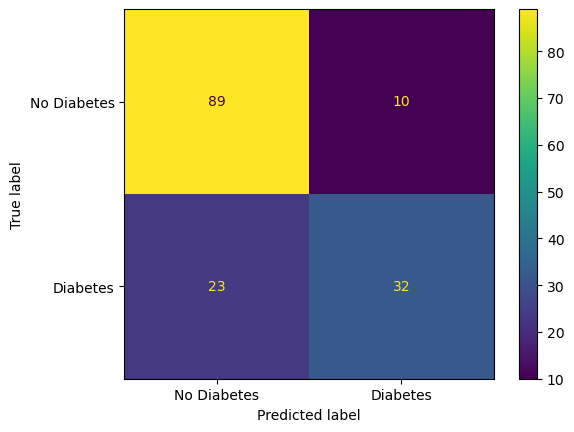

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['No Diabetes','Diabetes'])
cm_display.plot()
plt.show()

In [12]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print("TN:",TN,"FP:",FP,"FN:",FN,"TP:",TP)

TN: 89 FP: 10 FN: 23 TP: 32


In [13]:
accuracy=(TN+TP)/(TN+TP+FN+FP)
print(accuracy)

0.7857142857142857


In [15]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

Accuracy Score: 0.7857142857142857


In [16]:
error_rate=(FN+FP)/(TN+TP+FN+FP)
print(error_rate)

0.21428571428571427


In [17]:
print("Error rate:",1-accuracy_score(y_test,prediction))

Error rate: 0.2142857142857143


In [18]:
sensitivity=TP/(TP+FN)
print(sensitivity)

0.5818181818181818


In [20]:
specificity=TN/(TN+FP)
print(specificity)

0.898989898989899


In [22]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,prediction))#pos_label=1
print("Specificity:",recall_score(y_test,prediction,pos_label=0))

Sensitivity: 0.5818181818181818
Specificity: 0.898989898989899


In [23]:
precision_score=TP/(TP+FP)
print(precision_score)

0.7619047619047619


In [25]:
from sklearn.metrics import precision_score
print("Precision Score(For Positive):",precision_score(y_test,prediction))

Precision Score(For Positive): 0.7619047619047619


In [26]:
print("Precision Score(For Negative):",precision_score(y_test,prediction,pos_label=0))

Precision Score(For Negative): 0.7946428571428571


In [5]:
l=[]
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
for i in range(1,31):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    prediction=model.predict(x_test)
    l.append(accuracy_score(y_test,prediction))
l

[0.7207792207792207,
 0.7272727272727273,
 0.7402597402597403,
 0.7207792207792207,
 0.7337662337662337,
 0.7727272727272727,
 0.7597402597402597,
 0.7662337662337663,
 0.7662337662337663,
 0.7597402597402597,
 0.7467532467532467,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7857142857142857,
 0.7857142857142857,
 0.7857142857142857,
 0.7727272727272727,
 0.7727272727272727,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7662337662337663,
 0.7792207792207793,
 0.7532467532467533,
 0.7727272727272727,
 0.7532467532467533,
 0.7662337662337663,
 0.7662337662337663,
 0.7792207792207793]

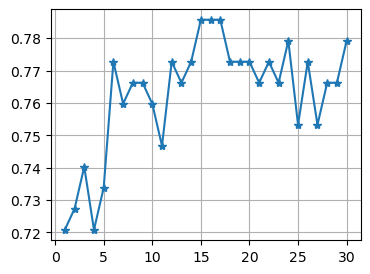

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(range(1,31),l,marker="*")
plt.grid(True)
plt.show()

In [7]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [8]:
x=df.iloc[:,0:2]
y=df['Size']
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [10]:
diff=pd.DataFrame({'Actual':y,"Predicted":prediction})
diff

,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [11]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


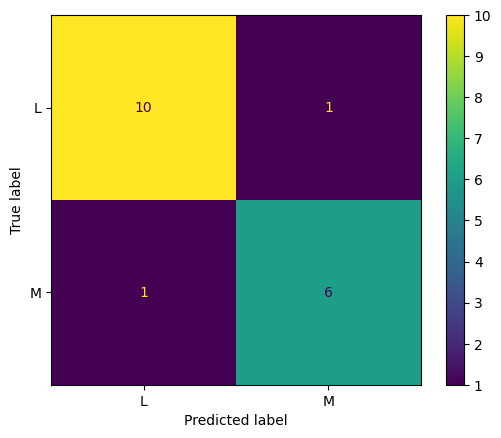

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['L','M'])
cm_display.plot()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 0.8888888888888888


In [17]:
print("Error rate:",1-accuracy_score(y,prediction))

Error rate: 0.11111111111111116


In [21]:
from sklearn.metrics import precision_score
print("Precision Score:",precision_score(y,prediction,pos_label="M"))

Precision Score: 0.8571428571428571


In [25]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y,prediction,pos_label="M"))
print("Specificity:",recall_score(y,prediction,pos_label="L"))

Sensitivity: 0.8571428571428571
Specificity: 0.9090909090909091


In [60]:
import pandas as pd
df=pd.read_csv("aptitudecommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhuvan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Speaker
4,dinesh,8,6.0,Intel
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Leader
8,Govind,8,3.0,Intel
9,Shushant,6,5.5,Speaker


In [37]:
x=df.iloc[:,1:3]
y=df['Class']
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [54]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Intel' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Intel' 'Intel' 'Leader' 'Intel' 'Leader']


In [55]:
diff=pd.DataFrame({'Actual':y,"Predicted":prediction})
diff

,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Intel
3,Speaker,Intel
4,Intel,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Leader,Speaker
8,Intel,Intel
9,Speaker,Intel


In [56]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[4 1 0]
 [1 2 1]
 [2 0 3]]


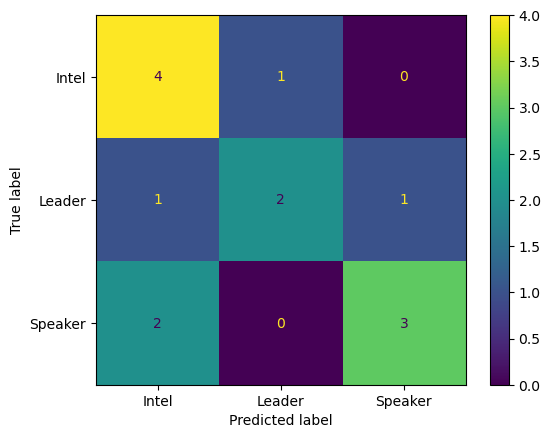

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['Intel','Leader','Speaker'])
cm_display.plot()
plt.show()

In [58]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 0.6428571428571429


In [63]:
import pandas as pd
df=pd.read_csv("AptitudeCommunication (1).csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader
